In [1]:
import numpy as np

# Add this only if NumPy doesn't have find_common_type (NumPy 2.0+)
if not hasattr(np, "find_common_type"):
    def _find_common_type(array_types, scalar_types=None):
        """
        Simple replacement for the old np.find_common_type
        that works for how pyspatialml uses it.
        pyspatialml calls: np.find_common_type(self.dtypes, [])
        So we can just use np.result_type on the array dtypes.
        """
        if array_types is None:
            array_types = []
        # pyspatialml only passes dtypes here, scalar_types is []
        return np.result_type(*array_types)

    np.find_common_type = _find_common_type


In [2]:
from pyspatialml import Raster
import os
import matplotlib.pyplot as plt
import geopandas
import pandas as pd
import seaborn as sn
import rasterio.plot
import numpy as np
import matplotlib as mpl
import os
import geopandas as gpd
import numpy as np
from tempfile import NamedTemporaryFile
import warnings
warnings.filterwarnings('ignore')

In [3]:
os.chdir('C:/Flood Data/Flood Factors/Resample_Factors')

In [4]:
data=pd.read_csv('Flood_extractvalues_New_duplicate.csv')

In [5]:
data=data.drop(columns=['Mean_RX3day_Rainfall'])

In [6]:
data.describe()

,Aspect,Elevation,Slope,Profile_curvature,Plan_curvature,Mean_RX1day_Rainfall,Mean_Annual_Rainfall,NDVI,LULC,SPI,TWI,Soil,Geology,NDWI,Distance_from_streams,Drainage_Density,Class
count,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000
mean,178.826617,2027.511785,21.833692,-0.063221,0.068227,80.848200,1606.805118,0.160585,15.572391,2.785065,5.696693,1.811448,11.855219,-0.351580,755.849181,0.368654,0.494949
std,95.529164,1215.681369,14.561834,1.152774,1.060527,12.376830,224.865355,0.112481,3.160511,3.291493,2.274942,0.719988,4.035641,0.225494,677.035529,0.163862,0.500818
min,-1.000000,494.000000,0.000000,-10.240000,-4.690824,38.070221,944.073303,-0.074921,9.000000,-11.212821,2.056899,1.000000,1.000000,-0.793756,0.000000,0.000000,0.000000
25%,96.009003,936.000000,8.984877,-0.640000,-0.480000,74.048729,1462.186279,0.074466,12.000000,1.949905,4.350558,1.000000,9.000000,-0.546507,372.050568,0.249398,0.000000
50%,184.899094,1692.000000,20.188250,-0.088615,0.000000,80.255363,1586.665039,0.149695,16.000000,3.287170,5.159569,2.000000,11.000000,-0.363007,526.158936,0.403678,0.000000
75%,249.676865,2889.000000,31.978168,0.537600,0.578462,87.662811,1769.321655,0.225501,17.000000,4.510977,6.407440,2.000000,16.000000,-0.184252,1116.151611,0.493859,1.000000
max,357.563354,4857.000000,59.550037,5.120000,9.702400,118.075333,2262.140381,0.544761,21.000000,11.321247,18.858854,4.000000,16.000000,0.117029,3200.500000,0.665181,1.000000


In [7]:
predictors = ['Aspect.tif', 'Elevation.tif',  'Slope.tif', 'Profile_curvature.tif', 'Plan_curvature.tif', 'Mean_RX1day_Rainfall.tif', 'Mean_Annual_Rainfall.tif', 'NDVI.tif', 'LULC.tif', 'SPI.tif', 'TWI.tif', 'Soil.tif','Geology.tif','NDWI.tif','Distance_from_streams.tif','Drainage_Density.tif']

In [8]:
stack = Raster(predictors)

In [9]:
stack.names

dict_keys(['Aspect', 'Elevation', 'Slope', 'Profile_curvature', 'Plan_curvature', 'Mean_RX1day_Rainfall', 'Mean_Annual_Rainfall', 'NDVI', 'LULC', 'SPI', 'TWI', 'Soil', 'Geology', 'NDWI', 'Distance_from_streams', 'Drainage_Density'])

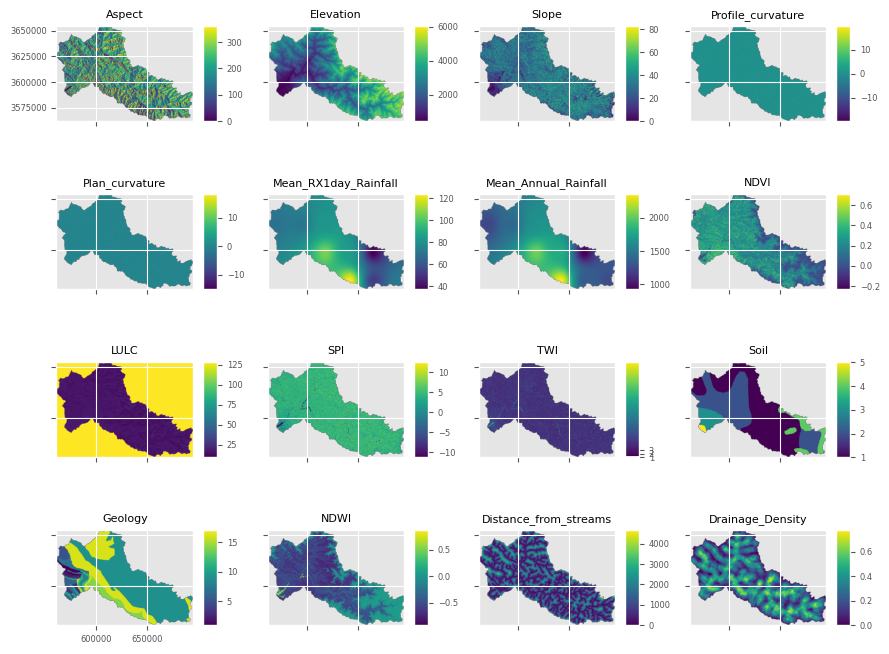

In [10]:
mpl.style.use('ggplot')
axs = stack.plot(figsize=(9, 7))
ax = axs.flatten()[10]
im = ax.images
im[0].colorbar.set_ticks([1,2,3])
ax = axs.flatten()[8]
ax.tick_params(axis='x', labelrotation=65)

plt.tight_layout()
plt.show()

In [11]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_validate
from sklearn.model_selection import train_test_split
from sklearn.metrics import make_scorer, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import GridSearchCV

In [12]:
#####    Index value identification ###########
soil_idx = list(stack.names).index("Soil")
LULC_idx = list(stack.names).index("LULC")
Geology_idx = list(stack.names).index("Geology")
# prequaternary_idx = list(stack.names).index("prequaternary")
#print(soil_idx, geomorphology_idx, underground_idx, prequaternary_idx)
print(soil_idx,LULC_idx,Geology_idx)

11 8 12


In [13]:
#index of categorical features from the dataset
categorical_features = [11,8,12] # 'LULC', 'geomorphology', 'underground', 'prequarternary'

In [14]:
#index of numerical features from the dataset
numerical_features = [0, 1, 2, 3, 4, 5,6,7,9,10,13,14,15]   #'dem_elevation', 'TWI', 'TPI', 'TRI', 'SPI', 'easterness', 'northerness', 'slope_std', 'distance_coast', 'distance_streams'

In [15]:
preprocessor = ColumnTransformer([
    ('ohe_soil', OneHotEncoder(categories='auto', handle_unknown='ignore'), categorical_features),
    ('num', StandardScaler(), numerical_features)])

In [16]:
X = data.loc[:, stack.names]
X[:3]


,Aspect,Elevation,Slope,Profile_curvature,Plan_curvature,Mean_RX1day_Rainfall,Mean_Annual_Rainfall,NDVI,LULC,SPI,TWI,Soil,Geology,NDWI,Distance_from_streams,Drainage_Density
0,288.434937,1676.0,7.209121,-1.024000,0.256000,73.709358,1459.744751,0.280242,17.0,0.496815,4.593312,2.0,9.0,-0.417748,372.050568,0.472717
1,234.865814,1697.0,44.725231,0.828993,-1.731007,73.811371,1444.912109,0.186464,16.0,5.206606,5.174378,2.0,7.0,-0.446055,2353.054443,0.187682
2,60.592812,3803.0,32.266174,-0.827077,0.452923,81.329865,1692.825928,0.092385,9.0,4.428362,4.371922,1.0,9.0,-0.523274,744.101135,0.318078


In [17]:
y = data["Class"]
y[:3]

0    0
1    0
2    0
Name: Class, dtype: int64

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_train.shape
X_test.shape

(90, 16)

In [19]:
print("Columns in data:", data.columns)
print("Columns in stack:", stack.names)


Columns in data: Index(['Aspect', 'Elevation', 'Slope', 'Profile_curvature', 'Plan_curvature',
       'Mean_RX1day_Rainfall', 'Mean_Annual_Rainfall', 'NDVI', 'LULC', 'SPI',
       'TWI', 'Soil', 'Geology', 'NDWI', 'Distance_from_streams',
       'Drainage_Density', 'Class'],
      dtype='object')
Columns in stack: dict_keys(['Aspect', 'Elevation', 'Slope', 'Profile_curvature', 'Plan_curvature', 'Mean_RX1day_Rainfall', 'Mean_Annual_Rainfall', 'NDVI', 'LULC', 'SPI', 'TWI', 'Soil', 'Geology', 'NDWI', 'Distance_from_streams', 'Drainage_Density'])


## R.f

In [21]:
# Type of scoring used to compare parameter combinations
from sklearn.model_selection import cross_validate, KFold
from sklearn.model_selection import GridSearchCV
acc_scorer = make_scorer(accuracy_score)
# Create the  grid for hyperparametertuning
grid_rf = {'classifier__n_estimators': [100, 200, 300, 400, 500, 600, 700, 800],
           'classifier__max_features': ['auto', 'sqrt', 'log2']}
print(grid_rf)
# Create a classifier
rf = RandomForestClassifier(random_state=42)
rf_flow = Pipeline([
    ('preproc', preprocessor),
    ('classifier', rf)
])
# Instantiate the grid search model with 10-fold cross-validation
kfold = KFold(n_splits=10, shuffle=True, random_state=42)
model_rf = GridSearchCV(rf_flow, param_grid = grid_rf, cv = kfold, scoring=acc_scorer)
model_rf.fit(X_train, y_train)

{'classifier__n_estimators': [100, 200, 300, 400, 500, 600, 700, 800], 'classifier__max_features': ['auto', 'sqrt', 'log2']}


,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'classifier__max_features': ['auto', 'sqrt', ...], 'classifier__n_estimators': [100, 200, ...]}"
,scoring,make_scorer(a...hod='predict')
,n_jobs,None
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('ohe_soil', ...), ('num', ...)]"


In [22]:
model_rf.best_params_
y_pred_rf = model_rf.predict(X_test)
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_rf, target_names = ['non-flood', 'flood']))
from sklearn.metrics import roc_auc_score
# Get probabilities for the positive class (flood)
y_prob_rf = model_rf.predict_proba(X_test)[:, 1]
auc_rf = roc_auc_score(y_test, y_prob_rf)
print("AUC Score (Random Forest):", round(auc_rf, 3))


              precision    recall  f1-score   support

   non-flood       0.96      0.96      0.96        45
       flood       0.96      0.96      0.96        45

    accuracy                           0.96        90
   macro avg       0.96      0.96      0.96        90
weighted avg       0.96      0.96      0.96        90

AUC Score (Random Forest): 0.991


In [ ]:
result_RF= stack.predict_proba(model_rf)
#result_RF.plot()
plt.show()

## Prediction

In [24]:
import os
from pyspatialml import Raster

# ================================================================
# 1️⃣ PATHS
# ================================================================
base_dir_static = r"C:\Flood Data\Flood Factors\Resample_Factors"
base_dir_future = r"C:\Flood Data\Flood Factors\IDW FUTURE\Resample"
out_dir = r"C:\Flood Data\Susceptibility Maps"
os.makedirs(out_dir, exist_ok=True)

# ================================================================
# 2️⃣ BASELINE PREDICTORS (same order as RF training)
# ================================================================
baseline_predictors = [
    os.path.join(base_dir_static, "Aspect.tif"),
    os.path.join(base_dir_static, "Elevation.tif"),
    os.path.join(base_dir_static, "Slope.tif"),
    os.path.join(base_dir_static, "Profile_curvature.tif"),
    os.path.join(base_dir_static, "Plan_curvature.tif"),
    os.path.join(base_dir_static, "Mean_RX1day_Rainfall.tif"),   # replace
    os.path.join(base_dir_static, "Mean_Annual_Rainfall.tif"),   # replace
    os.path.join(base_dir_static, "NDVI.tif"),
    os.path.join(base_dir_static, "LULC.tif"),
    os.path.join(base_dir_static, "SPI.tif"),
    os.path.join(base_dir_static, "TWI.tif"),
    os.path.join(base_dir_static, "Soil.tif"),
    os.path.join(base_dir_static, "Geology.tif"),
    os.path.join(base_dir_static, "NDWI.tif"),
    os.path.join(base_dir_static, "Distance_from_streams.tif"),
    os.path.join(base_dir_static, "Drainage_Density.tif"),
]

idx_rx1, idx_mean = 5, 6

# ================================================================
# 3️⃣ FUTURE SCENARIOS (2040, 2070, 2100)
# ================================================================
scenarios = {
    # ---------- SSP245 ----------
    "SSP245_2040": {
        "rx1":  os.path.join(base_dir_future, "Rainfall_RX1day_2040_ssp245.tif"),
        "mean": os.path.join(base_dir_future, "Mean_Rainfall_2040_ssp245.tif"),
    },
    "SSP245_2070": {
        "rx1":  os.path.join(base_dir_future, "Rainfall_RX1day_2070_ssp245.tif"),
        "mean": os.path.join(base_dir_future, "Mean_Rainfall_2070_ssp245.tif"),
    },
    "SSP245_2100": {
        "rx1":  os.path.join(base_dir_future, "Rainfall_RX1day_2100_ssp245.tif"),
        "mean": os.path.join(base_dir_future, "Mean_Rainfall_2100_ssp245.tif"),
    },

    # ---------- SSP585 ----------
    "SSP585_2040": {
        "rx1":  os.path.join(base_dir_future, "Rainfall_RX1day_2040_ssp585.tif"),
        "mean": os.path.join(base_dir_future, "Mean_Rainfall_2040_ssp585.tif"),
    },
    "SSP585_2070": {
        "rx1":  os.path.join(base_dir_future, "Rainfall_RX1day_2070_ssp585.tif"),
        "mean": os.path.join(base_dir_future, "Mean_Rainfall_2070_ssp585.tif"),
    },
    "SSP585_2100": {
        "rx1":  os.path.join(base_dir_future, "Rainfall_RX1day_2100_ssp585.tif"),
        "mean": os.path.join(base_dir_future, "Mean_Rainfall_2100_ssp585.tif"),
    },
}

# ================================================================
# 4️⃣ GENERATE RF FUTURE SUSCEPTIBILITY MAPS
# ================================================================
for scenario, files in scenarios.items():
    print(f"\n🌧️ Generating RF susceptibility map for {scenario}...")

    preds = baseline_predictors.copy()
    preds[idx_rx1]  = files["rx1"]
    preds[idx_mean] = files["mean"]

    stack_future = Raster(preds)

    # RF probability for flood class (class = 1)
    rf_result = stack_future.predict_proba(estimator=model_rf, indexes=[1])

    out_tif = os.path.join(out_dir, f"RF_FFS_{scenario}.tif")
    rf_result.write(file_path=out_tif, nodata=-9999)

    print(f"✅ Saved: {out_tif}")



🌧️ Generating RF susceptibility map for SSP245_2040...
✅ Saved: C:\Flood Data\Susceptibility Maps\RF_FFS_SSP245_2040.tif

🌧️ Generating RF susceptibility map for SSP245_2070...
✅ Saved: C:\Flood Data\Susceptibility Maps\RF_FFS_SSP245_2070.tif

🌧️ Generating RF susceptibility map for SSP245_2100...
✅ Saved: C:\Flood Data\Susceptibility Maps\RF_FFS_SSP245_2100.tif

🌧️ Generating RF susceptibility map for SSP585_2040...
✅ Saved: C:\Flood Data\Susceptibility Maps\RF_FFS_SSP585_2040.tif

🌧️ Generating RF susceptibility map for SSP585_2070...
✅ Saved: C:\Flood Data\Susceptibility Maps\RF_FFS_SSP585_2070.tif

🌧️ Generating RF susceptibility map for SSP585_2100...
✅ Saved: C:\Flood Data\Susceptibility Maps\RF_FFS_SSP585_2100.tif
